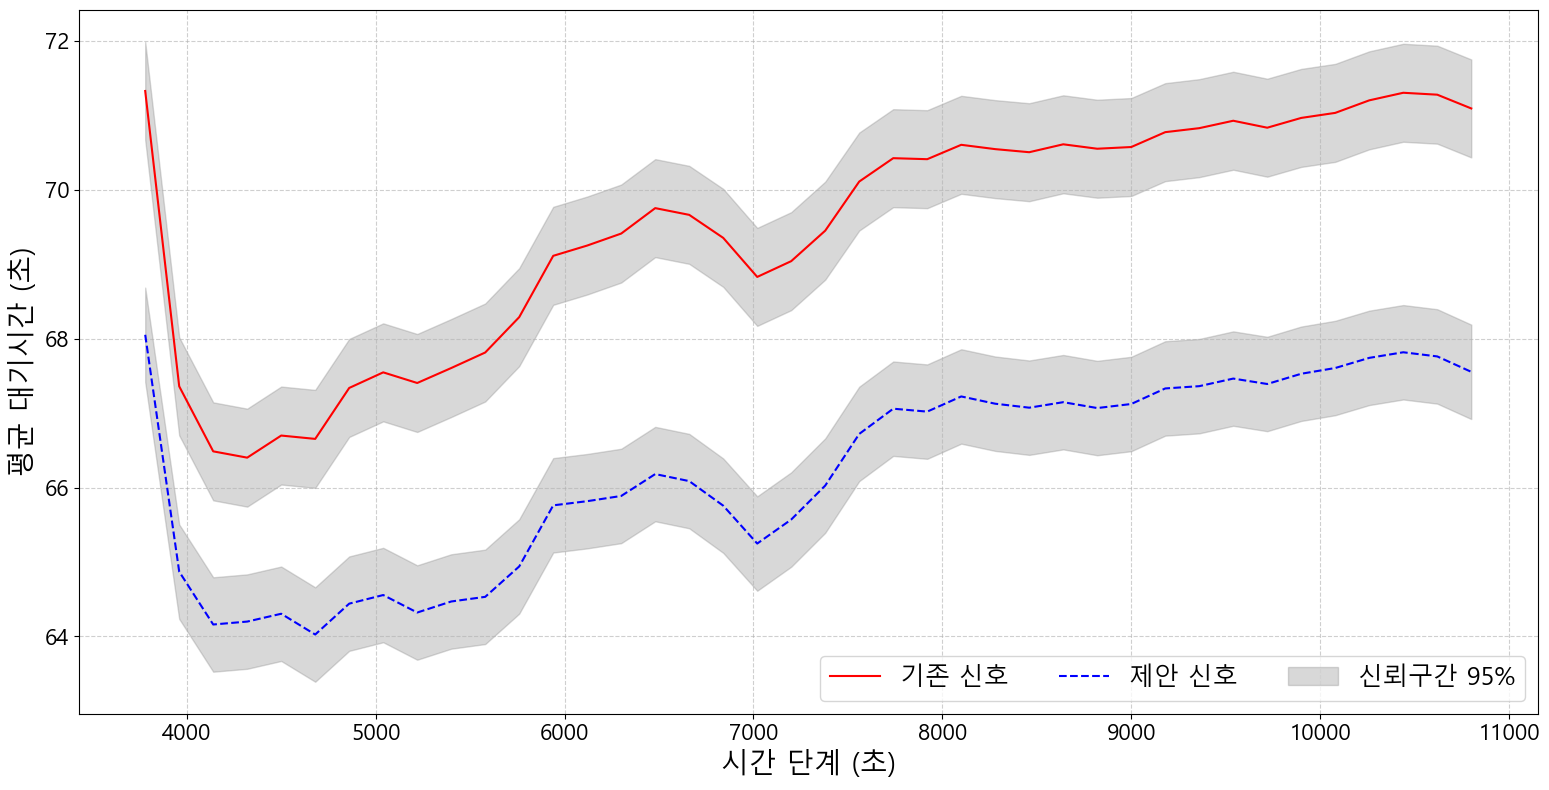

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

df_current = pd.read_csv('기존 신호 시뮬레이션 결과.csv')
df_pso = pd.read_csv('PSO 2 신호 시뮬레이션 결과.csv')

current_datasets = df_current.iloc[:,1:].values.tolist()
pso_datasets = df_pso.iloc[:,1:].values.tolist()

confidence_level = 0.95
n = len(current_datasets[0])
z = 1.96

upper_combined_current = np.zeros(n)
lower_combined_current = np.zeros(n)
upper_combined_pso = np.zeros(n)
lower_combined_pso = np.zeros(n)
x_values = np.linspace(3780, 10800, n)

# Calculate combined confidence intervals for the 'current' datasets
for i in range(n):
    means_current = [dataset[i] for dataset in current_datasets]
    std_devs_current = [np.std(dataset) for dataset in current_datasets]
    
    margin_errors_current = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_current]
    
    combined_mean_current = np.mean(means_current)
    combined_margin_error_current = np.sqrt(np.sum([error ** 2 for error in margin_errors_current]) / len(current_datasets))
    
    upper_combined_current[i] = combined_mean_current + combined_margin_error_current
    lower_combined_current[i] = combined_mean_current - combined_margin_error_current

# Calculate combined confidence intervals for the 'PSO' datasets
for i in range(n):
    means_pso = [dataset[i] for dataset in pso_datasets]
    std_devs_pso = [np.std(dataset) for dataset in pso_datasets]
    
    margin_errors_pso = [z * (std_dev / np.sqrt(n)) for std_dev in std_devs_pso]
    
    # Calculate the combined confidence interval (for the mean of 'PSO' datasets)
    combined_mean_pso = np.mean(means_pso)
    combined_margin_error_pso = np.sqrt(np.sum([error ** 2 for error in margin_errors_pso]) / len(pso_datasets))
    
    upper_combined_pso[i] = combined_mean_pso + combined_margin_error_pso
    lower_combined_pso[i] = combined_mean_pso - combined_margin_error_pso

plt.figure(figsize=(16, 8))

# Plot 'current' datasets
# for i, dataset in enumerate(current_datasets):
#     plt.plot(range(n), dataset, label=f'Current Dataset {i + 1}', linestyle='dashed')

# Plot 'PSO' datasets
# for i, dataset in enumerate(pso_datasets):
#     plt.plot(range(n), dataset, label=f'PSO Dataset {i + 1}')

plt.plot(np.linspace(3780, 10800, 40), [(np.mean([dataset[i] for dataset in current_datasets])) for i in range(n)], label='기존 신호', color='red')
plt.plot(np.linspace(3780, 10800, 40), [(np.mean([dataset[i] for dataset in pso_datasets])) for i in range(n)], '--', label='제안 신호', color='blue')
plt.fill_between(np.linspace(3780, 10800, 40), lower_combined_current, upper_combined_current, alpha=0.3, color='gray', label='신뢰구간 95%')
plt.fill_between(np.linspace(3780, 10800, 40), lower_combined_pso, upper_combined_pso, alpha=0.3, color='gray')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18)
plt.legend(fontsize=18, loc='upper center', bbox_to_anchor=(0.75, 0.1), ncol=3)
plt.xlabel('시간 단계 (초)', fontsize=20)
plt.ylabel('평균 대기시간 (초)', fontsize=20)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

df_waiting_result = pd.read_csv('waiting_result 결과.csv')
df_waiting_result1 = pd.read_csv('waiting_result2 결과.csv')

df_left_right_result = pd.read_csv('left_right_result 결과.csv')
df_left_right_result1 = pd.read_csv('left_right_result2 결과.csv')

df_right_left_result = pd.read_csv('right_left_result 결과.csv')
df_right_left_result1 = pd.read_csv('right_left_result2 결과.csv')

df_up_down_result = pd.read_csv('up_down_result 결과.csv')
df_up_down_result1 = pd.read_csv('up_down_result2 결과.csv')

df_down_up_result = pd.read_csv('down_up_result 결과.csv')
df_down_up_result1 = pd.read_csv('down_up_result2 결과.csv')

waiting_result = df_waiting_result.iloc[:,1:].values.ravel().tolist()
waiting_result3 = df_waiting_result1.iloc[:,1:].values.ravel().tolist()

left_right_result = df_left_right_result.iloc[:,1:].values.ravel().tolist()
left_right_result3 = df_left_right_result1.iloc[:,1:].values.ravel().tolist()

right_left_result = df_right_left_result.iloc[:,1:].values.ravel().tolist()
right_left_result3 = df_right_left_result1.iloc[:,1:].values.ravel().tolist()

up_down_result = df_up_down_result.iloc[:,1:].values.ravel().tolist()
up_down_result3 = df_up_down_result1.iloc[:,1:].values.ravel().tolist()

down_up_result = df_down_up_result.iloc[:,1:].values.ravel().tolist()
down_up_result3 = df_down_up_result1.iloc[:,1:].values.ravel().tolist()

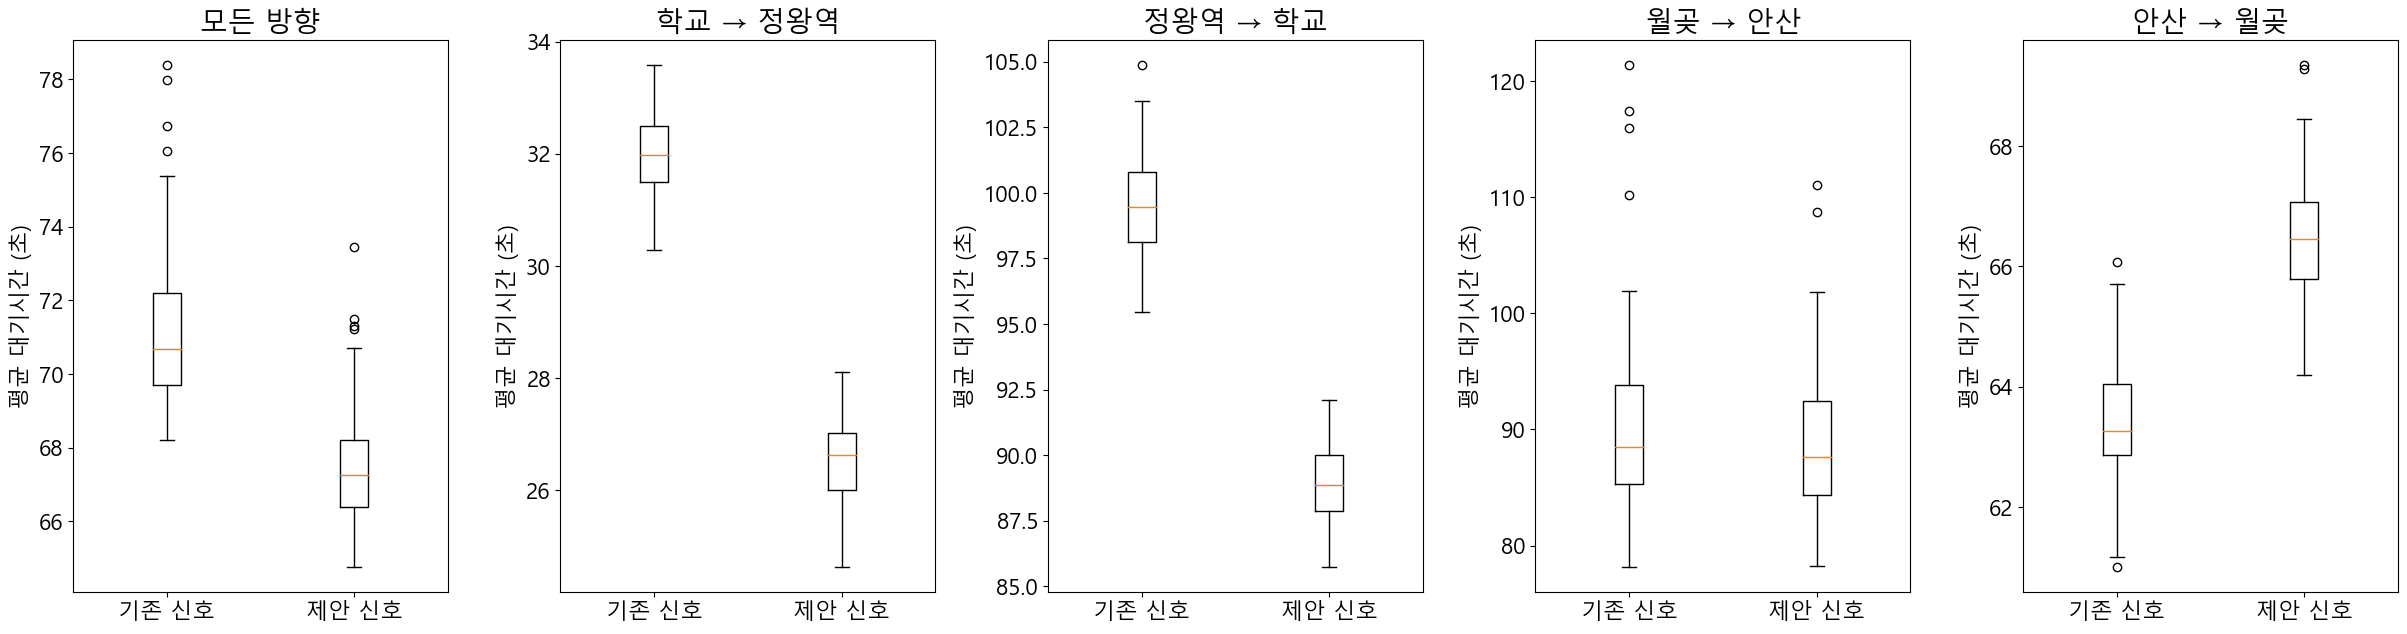

In [10]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

# Group data by categories
waiting_data = [waiting_result, waiting_result3]
left_right_data = [left_right_result, left_right_result3]
right_left_data = [right_left_result, right_left_result3]
up_down_data = [up_down_result, up_down_result3]
down_up_data = [down_up_result, down_up_result3]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
category_names = ['모든 방향', '학교 → 정왕역', '정왕역 → 학교', '월곶 → 안산', '안산 → 월곶']

# Create subplots with adjusted spacing and increased figure size
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=False, gridspec_kw={'wspace': 0.3})

# Define box style with wider boxes
boxprops = dict(linewidth=2, color='blue')

# Plot each category in a separate subplot
for i, ax in enumerate(axes):
    boxplot = ax.boxplot(data_categories[i])
    for box in boxplot['boxes']:
        box.set(linewidth=1)  # Set the box color and width
    ax.set_title(category_names[i], fontsize=20)
    ax.set_xticklabels(['기존 신호', '제안 신호'], fontsize=16)
    ax.set_ylabel('평균 대기시간 (초)', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()

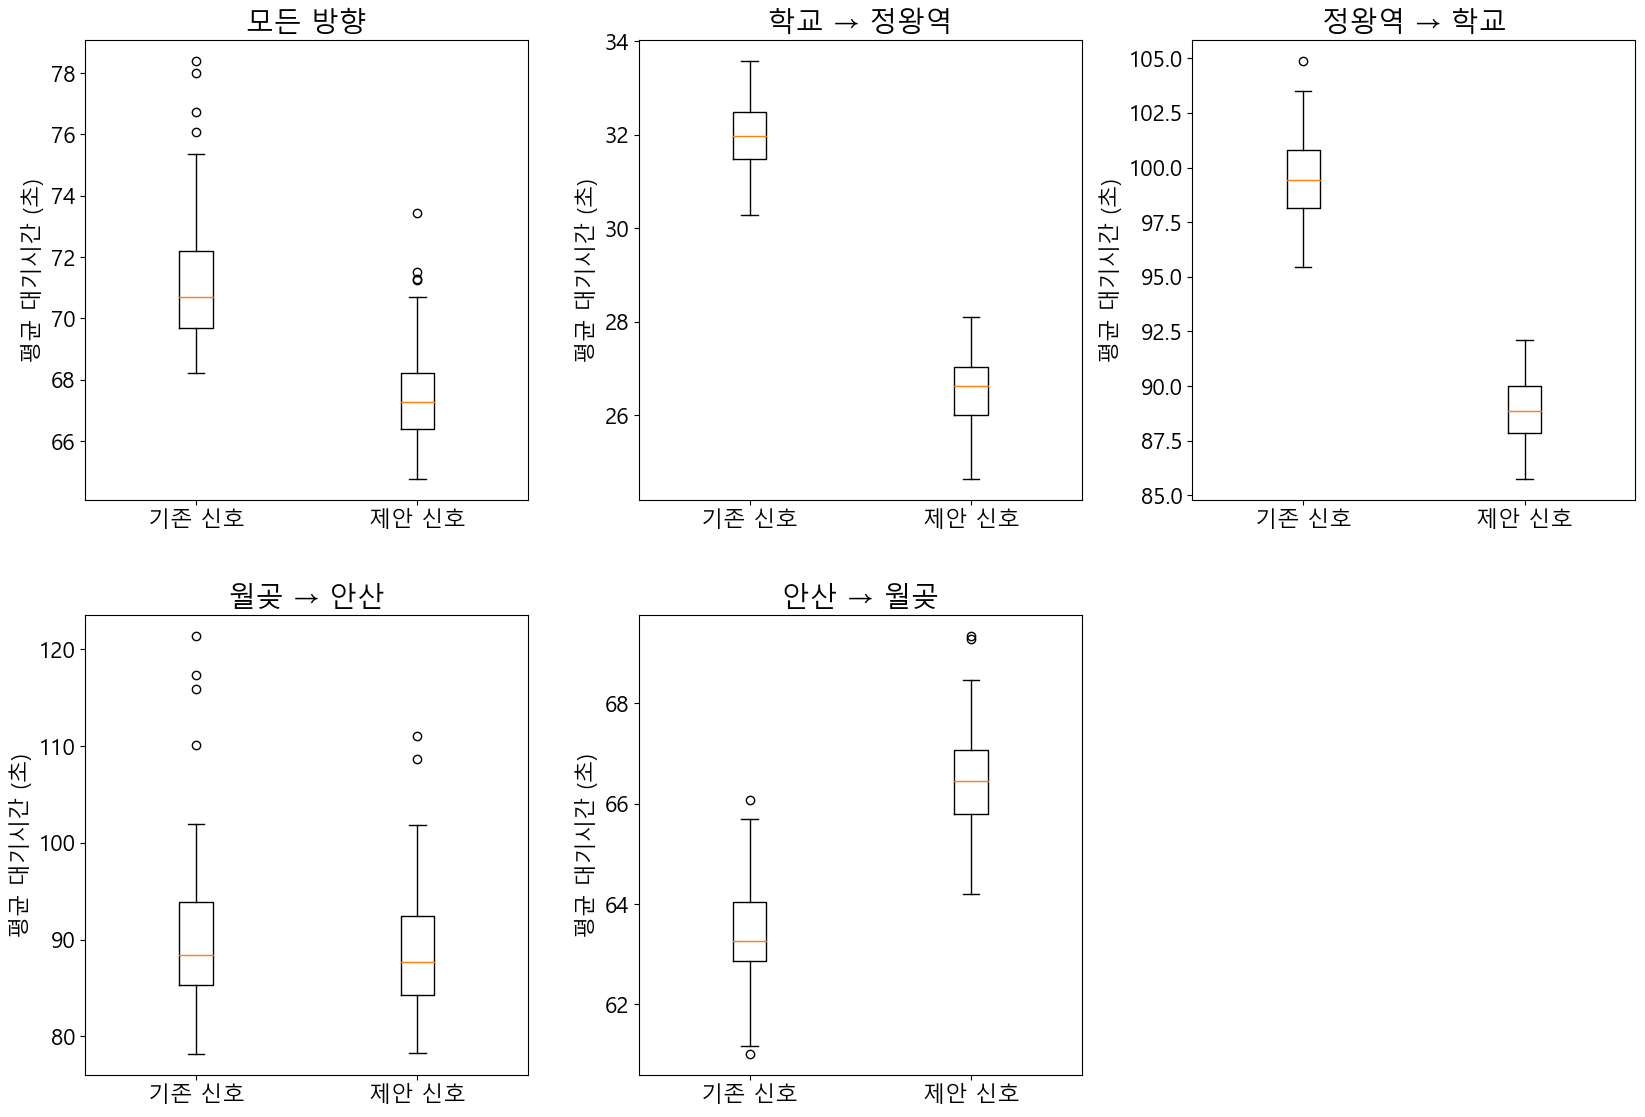

In [5]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

# Group data by categories
waiting_data = [waiting_result, waiting_result3]
left_right_data = [left_right_result, left_right_result3]
right_left_data = [right_left_result, right_left_result3]
up_down_data = [up_down_result, up_down_result3]
down_up_data = [down_up_result, down_up_result3]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
category_names = ['모든 방향', '학교 → 정왕역', '정왕역 → 학교', '월곶 → 안산', '안산 → 월곶']

# Create subplots with 3 rows and 2 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 15), sharey=False, gridspec_kw={'wspace': 0.25, 'hspace': 0.25})

# Plot each category in separate subplots
for i, ax in enumerate(axes.flat[:-1]):  # Exclude the last subplot
    if i < len(data_categories):
        boxplot = ax.boxplot(data_categories[i])
        for box in boxplot['boxes']:
            box.set(linewidth=1)  # Set the box color and width
        ax.set_title(category_names[i], fontsize=20)
        ax.set_xticklabels(['기존 신호', '제안 신호'], fontsize=16)
        ax.set_ylabel('평균 대기시간 (초)', fontsize=16)
        ax.tick_params(axis='both', labelsize=16)

# Remove the last subplot (3rd row, 2nd column)
fig.delaxes(axes[1, 2])

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()